# Phase 5.1: Exploratory Data Analysis (EDA)

This notebook performs Exploratory Data Analysis on the combined growth dataset to understand feature distributions, correlations, outliers, missing values, class imbalances, and data handling requirements before starting the machine learning phase.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

%matplotlib inline
sns.set_theme(style="whitegrid")

## 1. Load Dataset

In [2]:
# Navigate to data folder
data_path = Path("../data/features/combined_growth_dataset.csv")
print(f"Loading dataset from: {data_path.resolve()}")
df = pd.read_csv(data_path)
print(f"Shape: {df.shape}")

Loading dataset from: C:\Users\Sri Nidhi\Urban_Project\data\features\combined_growth_dataset.csv
Shape: (4594, 30)


## 2. Columns & Data Types

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4594 entries, 0 to 4593
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   city                     4594 non-null   object 
 1   grid_id                  4594 non-null   int64  
 2   building_count           4594 non-null   int64  
 3   building_density         4594 non-null   float64
 4   building_area_ratio      4594 non-null   float64
 5   road_length              4594 non-null   float64
 6   road_density             4594 non-null   float64
 7   road_intersection_count  4594 non-null   int64  
 8   intersection_density     4594 non-null   float64
 9   distance_to_highway      4594 non-null   float64
 10  green_area               4594 non-null   float64
 11  green_ratio              4594 non-null   float64
 12  distance_to_center       4594 non-null   float64
 13  mean_ndvi_2019           4594 non-null   float64
 14  mean_ndbi_2019          

## 3. Missing Value Analysis

In [4]:
missing_counts = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({"Missing Counts": missing_counts, "Percentage (%)": missing_pct})
print(missing_df[missing_df["Missing Counts"] > 0])

Empty DataFrame
Columns: [Missing Counts, Percentage (%)]
Index: []


## 4. Duplicate Check

In [5]:
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows detected: {duplicate_count}")

Duplicate rows detected: 0


## 5. Data Imbalance Analysis

In [6]:
cat_counts = df["change_category"].value_counts()
cat_pct = df["change_category"].value_counts(normalize=True) * 100
imbalance_df = pd.DataFrame({"Counts": cat_counts, "Percentage (%)": cat_pct})
print("=== Class Proportions (Overall) ===")
print(imbalance_df)
print("\n=== Class Proportions (City-Wise) ===")
print(df.groupby(["city", "change_category"]).size().unstack(fill_value=0))

=== Class Proportions (Overall) ===
                 Counts  Percentage (%)
change_category                        
High               1563       34.022638
Low                1516       32.999565
Medium             1515       32.977797

=== Class Proportions (City-Wise) ===
change_category  High  Low  Medium
city                              
Bengaluru         478  463     463
Hyderabad         703  683     682
Pune              382  370     370


## 6. Descriptive Statistics

In [7]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if "grid_id" in numerical_cols:
    numerical_cols.remove("grid_id")

df[numerical_cols].describe()

,building_count,building_density,building_area_ratio,road_length,road_density,road_intersection_count,intersection_density,distance_to_highway,green_area,green_ratio,...,delta_ndvi,delta_ndbi,delta_ndwi,abs_delta_ndvi,abs_delta_ndbi,abs_delta_ndwi,norm_delta_ndvi,norm_delta_ndbi,norm_delta_ndwi,urban_change_index
count,4594.000000,4594.000000,4594.000000,4594.000000,4594.000000,4594.000000,4594.000000,4594.000000,4594.000000,4594.000000,...,4594.000000,4594.000000,4594.000000,4594.000000,4594.000000,4594.000000,4594.000000,4594.000000,4594.000000,4594.000000
mean,399.990205,399.990205,0.077147,26890.477247,26.890477,114.199391,114.199391,915.333872,40277.272424,0.040277,...,0.016175,-0.004243,-0.007142,0.041612,0.025966,0.035052,0.411348,0.425254,0.532548,0.429457
std,616.035205,616.035205,0.096423,18243.342215,18.243342,106.852315,106.852315,1019.746585,108285.343949,0.108285,...,0.064987,0.037502,0.063582,0.052470,0.027388,0.053523,0.097932,0.112757,0.118592,0.116210
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.205515,0.000000,0.000000,...,-0.778977,-0.209978,-0.519094,0.000008,0.000003,0.000023,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000282,11509.570149,11.509570,25.000000,25.000000,229.162390,0.000000,0.000000,...,-0.007410,-0.020124,-0.032193,0.011064,0.007673,0.009926,0.348991,0.346095,0.460855,0.346713
50%,109.000000,109.000000,0.032592,24319.656183,24.319656,83.500000,83.500000,561.471812,21.089319,0.000021,...,0.012940,-0.000565,-0.009653,0.024623,0.017479,0.021832,0.394003,0.404264,0.523534,0.407598
75%,536.000000,536.000000,0.129043,40649.863830,40.649864,181.000000,181.000000,1232.641919,27934.190625,0.027934,...,0.040824,0.015819,0.010268,0.054354,0.034668,0.043669,0.476262,0.510758,0.634466,0.519393
max,4949.000000,4949.000000,0.506641,88351.825235,88.351825,714.000000,714.000000,7929.876750,1000000.000000,1.000000,...,0.468952,0.324097,0.846815,0.778977,0.324097,0.846815,1.000000,1.000000,1.000000,1.000000


## 7. Feature Correlation Heatmap

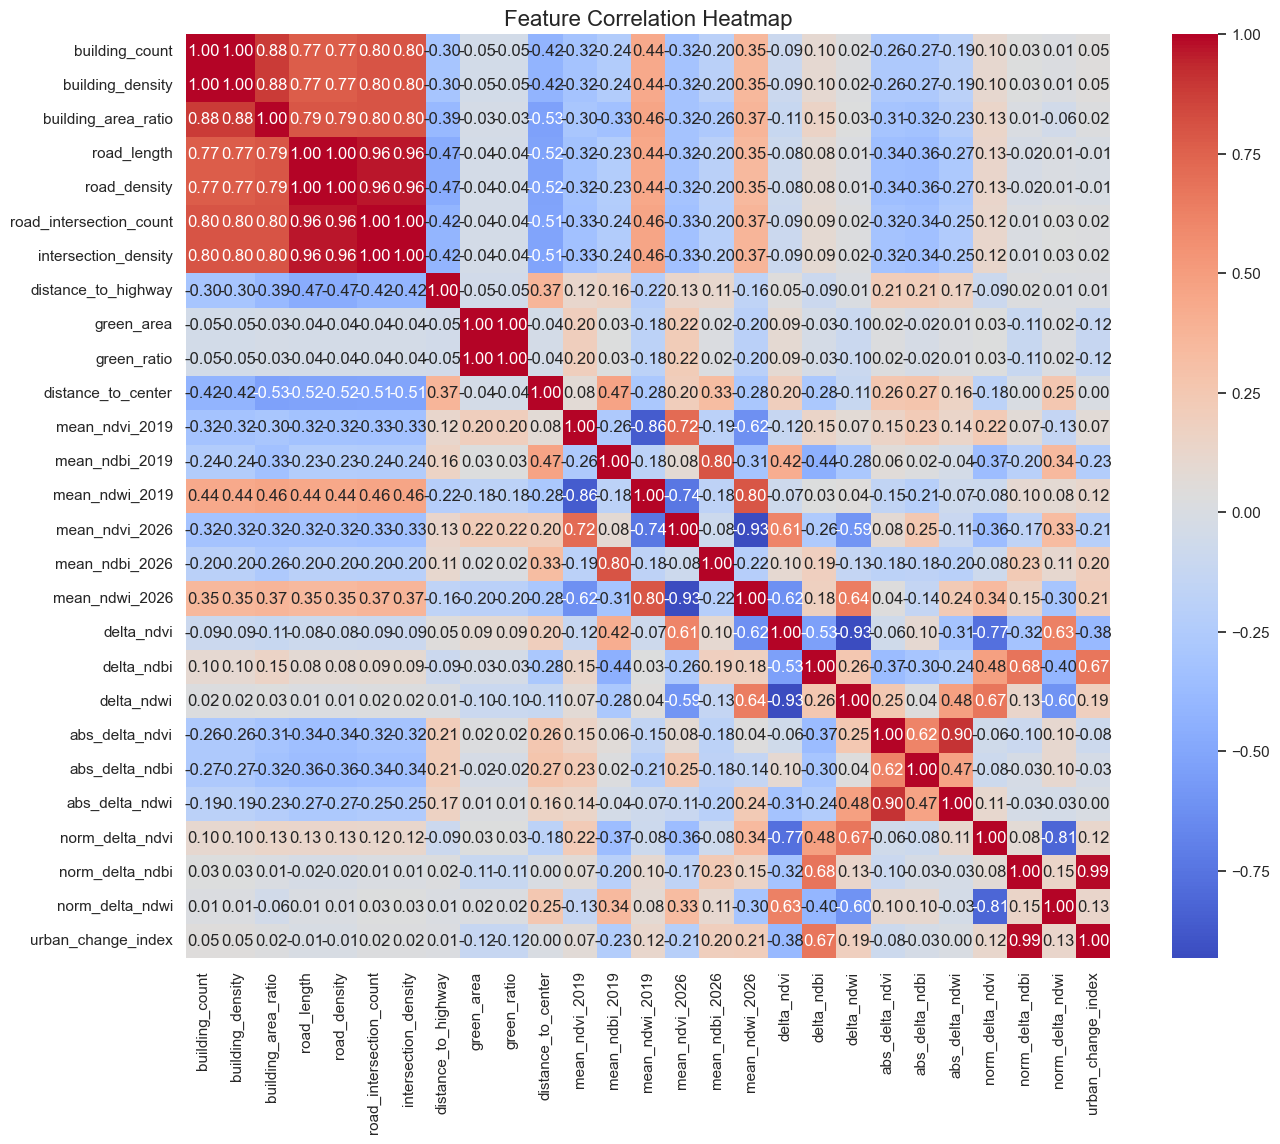

In [8]:
corr_matrix = df[numerical_cols].corr()
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)
plt.title("Feature Correlation Heatmap", fontsize=16)
plt.show()

## 8. Target Distributions

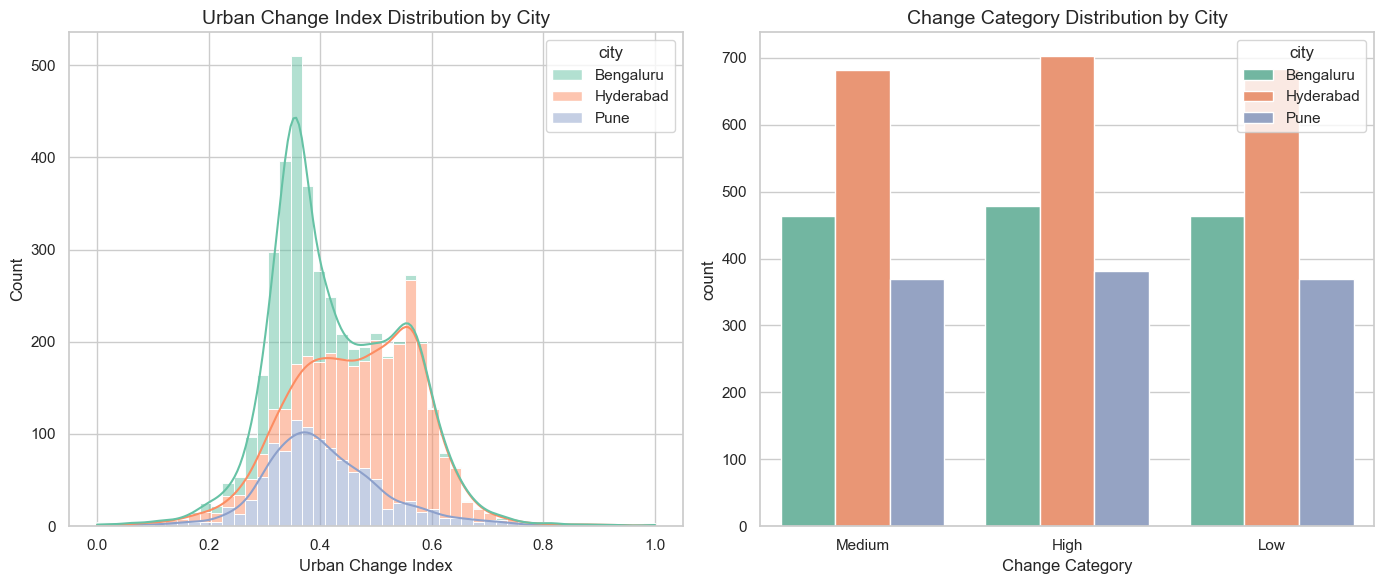

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(data=df, x="urban_change_index", hue="city", kde=True, multiple="stack", ax=axes[0], palette="Set2")
axes[0].set_title("Urban Change Index Distribution by City", fontsize=14)
axes[0].set_xlabel("Urban Change Index")

sns.countplot(data=df, x="change_category", hue="city", ax=axes[1], palette="Set2")
axes[1].set_title("Change Category Distribution by City", fontsize=14)
axes[1].set_xlabel("Change Category")

plt.tight_layout()
plt.show()

## 9. Feature Distributions

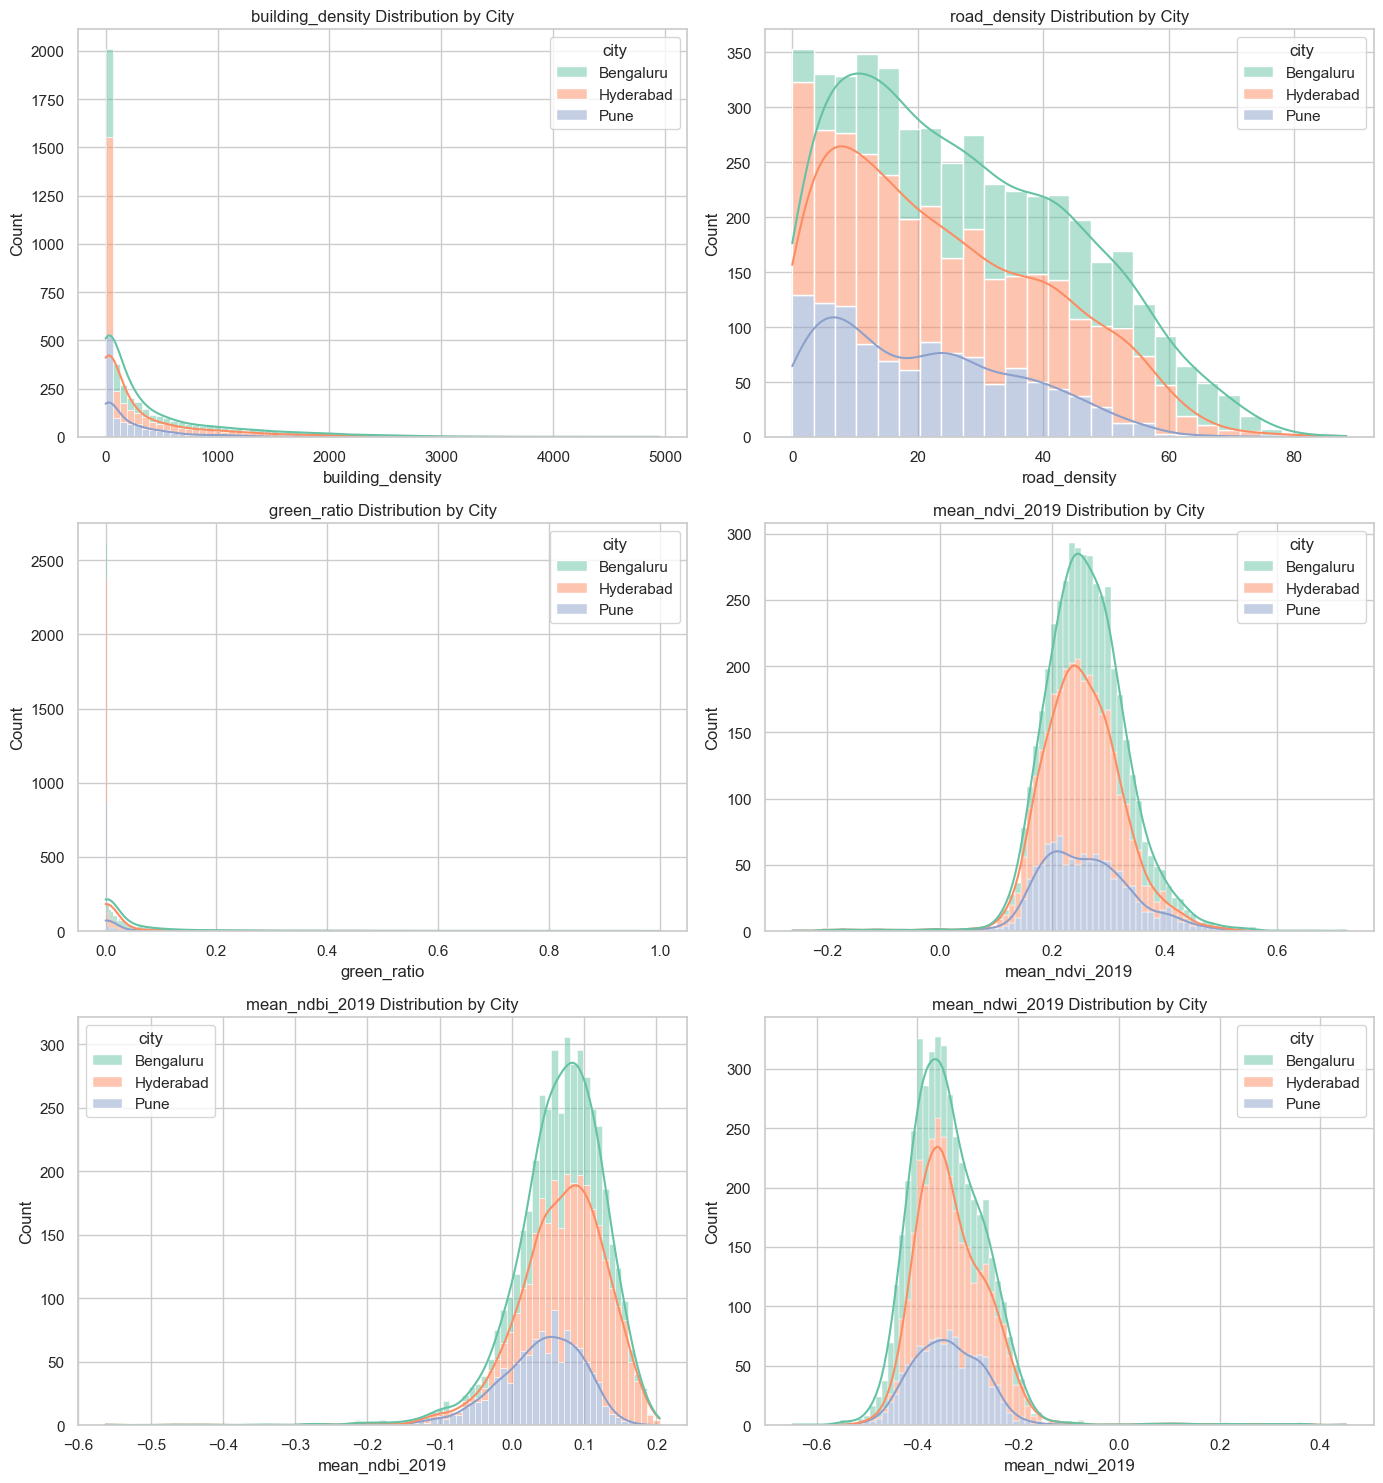

In [10]:
features_to_plot = [
    "building_density", "road_density", "green_ratio",
    "mean_ndvi_2019", "mean_ndbi_2019", "mean_ndwi_2019"
]

fig, axes = plt.subplots(3, 2, figsize=(14, 15))
axes = axes.flatten()

for idx, col in enumerate(features_to_plot):
    sns.histplot(data=df, x=col, hue="city", kde=True, multiple="stack", ax=axes[idx], palette="Set2")
    axes[idx].set_title(f"{col} Distribution by City", fontsize=12)
    axes[idx].set_xlabel(col)
    
plt.tight_layout()
plt.show()

## 10. Outliers Check via Boxplots

C:\Users\Sri Nidhi\AppData\Local\Temp\ipykernel_7276\1397293351.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="city", y=col, ax=axes[idx], palette="Set2")
C:\Users\Sri Nidhi\AppData\Local\Temp\ipykernel_7276\1397293351.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="city", y=col, ax=axes[idx], palette="Set2")
C:\Users\Sri Nidhi\AppData\Local\Temp\ipykernel_7276\1397293351.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="city", y=col, ax=axes[idx], palette="Set2")
C:\Users\Sri Nidhi\AppData\Loca

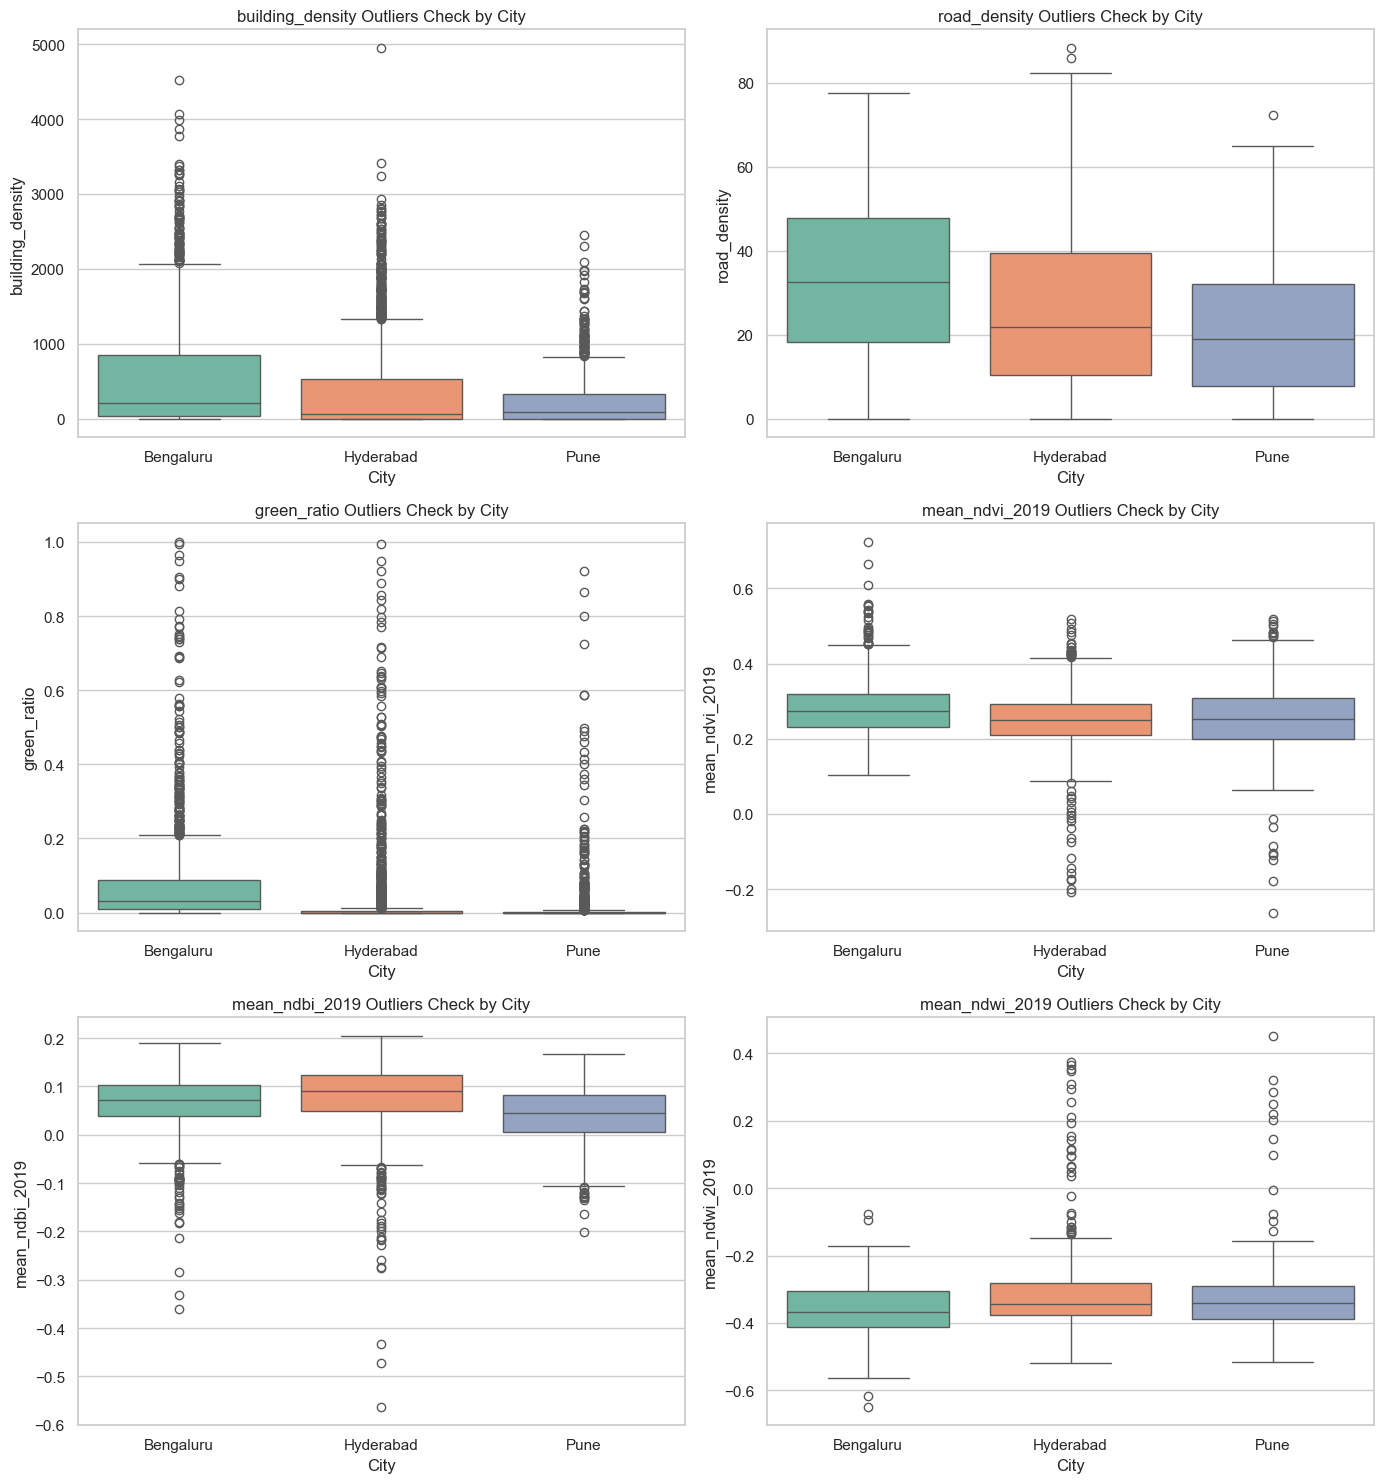

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
axes = axes.flatten()

for idx, col in enumerate(features_to_plot):
    sns.boxplot(data=df, x="city", y=col, ax=axes[idx], palette="Set2")
    axes[idx].set_title(f"{col} Outliers Check by City", fontsize=12)
    axes[idx].set_xlabel("City")
    axes[idx].set_ylabel(col)
    
plt.tight_layout()
plt.show()

## 11. City-Wise Feature Means

In [12]:
df.groupby("city")[numerical_cols].mean()

,building_count,building_density,building_area_ratio,road_length,road_density,road_intersection_count,intersection_density,distance_to_highway,green_area,green_ratio,...,delta_ndvi,delta_ndbi,delta_ndwi,abs_delta_ndvi,abs_delta_ndbi,abs_delta_ndwi,norm_delta_ndvi,norm_delta_ndbi,norm_delta_ndwi,urban_change_index
city,,,,,,,,,,,,,,,,,,,,,
Bengaluru,566.626781,566.626781,0.103204,34029.686355,34.029686,153.790598,153.790598,621.501989,78714.232284,0.078714,...,0.008132,-0.003681,-0.001916,0.030967,0.019895,0.027566,0.486786,0.353056,0.485299,0.353830
Hyderabad,373.687621,373.687621,0.064852,25315.125967,25.315126,108.274178,108.274178,1008.861884,26303.308174,0.026303,...,0.030579,-0.015322,-0.016757,0.058589,0.033069,0.049153,0.351280,0.484563,0.632232,0.492651
Pune,239.950980,239.950980,0.067203,20860.510099,20.860510,75.578431,75.578431,1110.631585,17935.620396,0.017936,...,-0.000308,0.015472,0.004042,0.023639,0.020469,0.018430,0.427660,0.406284,0.407939,0.407614
